# Introduction
## Financial Fraud Detection using FinBERT + Logistic Regression

### Project Objective
The objective of this project is to detect fraudulent financial text using Natural Language Processing (NLP) and Machine Learning techniques.

Fraud detection is critical in financial systems to prevent financial losses and identify suspicious activities automatically.

This project uses the **AmitKedia financial text dataset** and applies:
- FinBERT (financial language model) for feature extraction
- Logistic Regression for classification

---

### Why This Approach?

The dataset contains only **170 samples**, which is relatively small for deep learning fine-tuning.

Fine-tuning large transformer models like BERT usually requires thousands of samples. With small datasets, fine-tuning can lead to severe overfitting.

Therefore:
- FinBERT is used as a **feature extractor** to generate contextual embeddings
- Logistic Regression is used as a **stable classifier for small datasets**
- This approach provides reliable and interpretable results


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import torch
import pickle

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

from transformers import AutoTokenizer, AutoModel


# 1. Data Exploration and Preprocessing

### Dataset Description
The dataset used in this project originates from the **Amit Kedia Financial Statement Fraud Detection Dataset**, which contains **textual financial filings** extracted from corporate reports.
Each record represents a company’s **financial disclosure text** labeled as either:
- **Fraud = “yes”** → fraudulent financial statement  
- **Fraud = “no”** → legitimate financial statement  

| Feature | Description |
|:----------|:-------------|
| **Fillings** | Text content extracted from company filings (e.g., annual reports, disclosures). |
| **Fraud** | Target variable indicating whether the statement is fraudulent (`yes` / `no`). |


In [2]:
#load the dataset
df = pd.read_csv('C:/Users/user/Documents/data_science_bootcamp_challenges_project/capstone_project/amit_kedia_dataset.csv')
df.head()


,Fillings,Fraud
0,nanitem 14 exhibits financial statements repor...,yes
1,item 14 principal accounting fees services mat...,no
2,item 14 exhibits financial statements schedule...,yes
3,item 14 exhibits financial statement schedules...,yes
4,item 14 exhibits financial statement schedules...,no


In [3]:
df.shape

(170, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Fillings  170 non-null    object
 1   Fraud     170 non-null    object
dtypes: object(2)
memory usage: 2.8+ KB


In [5]:
print(df['Fraud'].value_counts())

Fraud
yes    85
no     85
Name: count, dtype: int64


In [6]:
df.isnull().sum()

Fillings    0
Fraud       0
dtype: int64

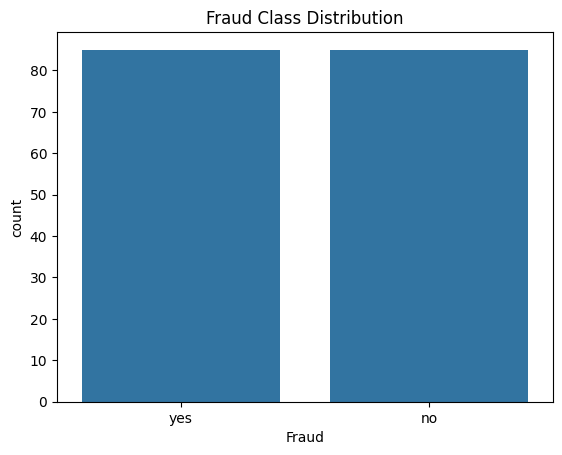

In [7]:
sns.countplot(data=df, x='Fraud')
plt.title('Fraud Class Distribution')
plt.show()

### Text Preprocessing

In [8]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9 ]', '', text)
    return text

df['clean_text'] = df['Fillings'].apply(clean_text)

df[['Fillings','clean_text']].head()

,Fillings,clean_text
0,nanitem 14 exhibits financial statements repor...,nanitem 14 exhibits financial statements repor...
1,item 14 principal accounting fees services mat...,item 14 principal accounting fees services mat...
2,item 14 exhibits financial statements schedule...,item 14 exhibits financial statements schedule...
3,item 14 exhibits financial statement schedules...,item 14 exhibits financial statement schedules...
4,item 14 exhibits financial statement schedules...,item 14 exhibits financial statement schedules...


In [9]:
df['Fraud'] = df['Fraud'].str.lower().str.strip()
df['Fraud'] = df['Fraud'].map({'no':0, 'yes':1})

In [10]:
df['Fraud'].value_counts()

Fraud
1    85
0    85
Name: count, dtype: int64

### Train-Test Split

In [11]:
X = df['clean_text']   # cleaned text column
y = df['Fraud']        # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


Train size: 136
Test size: 34


# 2. Feature Engineering with FinBERT

In this step, raw financial text is transformed into numerical representations using FinBERT, a transformer model pretrained on financial corpora.
Rather than fine-tuning the transformer model (which would require a large dataset), FinBERT is used as a feature extractor. The [CLS] token embedding is extracted for each text sample, resulting in a 768-dimensional vector representation.
These embeddings capture contextual and semantic information specific to financial language, providing rich features for the downstream classification model.


### Why "yiyanghkust/finbert-tone" Was Selected

The "yiyanghkust/finbert-tone" model was selected because it is a transformer model specifically pretrained on financial text. Unlike general-purpose language models, this model has been trained on financial corpora, enabling it to better understand domain-specific terminology, financial reporting language, and contextual nuances.
Although the model is fine-tuned for financial sentiment analysis, it provides high-quality contextual embeddings that capture subtle tone, uncertainty, and risk-related expressions commonly present in fraudulent financial statements.
Since the AmitKedia dataset consists of financial text with complex and nuanced language, using a domain-specific model such as FinBERT ensures richer semantic representations compared to general NLP models.
Therefore, "yiyanghkust/finbert-tone" was used as a feature extractor to generate meaningful financial embeddings for downstream fraud classification.

In [12]:
tokenizer = AutoTokenizer.from_pretrained("yiyanghkust/finbert-tone")
finbert_model = AutoModel.from_pretrained("yiyanghkust/finbert-tone" )

### Embedding Function
To convert financial text into numerical features, a custom embedding function was implemented using FinBERT.
For each input text:
1. The text is tokenized using the FinBERT tokenizer.
2. The tokenized input is passed through the pretrained FinBERT model.
3. The embedding corresponding to the `[CLS]` token is extracted.

The `[CLS]` token is a special classification token added at the beginning of every input sequence in BERT-based models. Its embedding captures the overall contextual representation of the entire text.

In [13]:
def get_embeddings(text_list):
    embeddings = []
    
    for text in text_list:
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=128
        )
        
        with torch.no_grad():
            outputs = finbert_model(**inputs)
        
        cls_embedding = outputs.last_hidden_state[:,0,:].numpy()
        embeddings.append(cls_embedding[0])
        
    return np.array(embeddings)

### Generate Embeddings

The embedding function is applied to both the training and test datasets:

- Each financial text sample is converted into a 768-dimensional numerical vector.
- These vectors serve as input features for the Logistic Regression classifier.

Using the `[CLS]` token embedding provides a compact and semantically rich representation of financial text, making it suitable for downstream classification tasks such as fraud detection.

In [14]:
#generate finbert embeddings
X_train_emb = get_embeddings(X_train.tolist())
X_test_emb = get_embeddings(X_test.tolist())

print("Embedding shape:", X_train_emb.shape)

Embedding shape: (136, 768)


# 3. Model Selection and Training

Logistic Regression is chosen because:
- Works well on small datasets
- Less prone to overfitting
- Fast and interpretable


In [15]:
model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced", #class_weight="balanced": Adjusts weights inversely proportional to class frequencies
    C=0.5, #Applies stronger regularization (compared to default C=1.0)
    solver="liblinear" # - solver="liblinear": Suitable for small datasets and binary classification problems,
                            #   providing stable optimization.
)

# Train the model using FinBERT embeddings as input features
model.fit(X_train_emb, y_train)

LogisticRegression(C=0.5, class_weight='balanced', max_iter=3000,
                   solver='liblinear')

# 4. Model Evaluation

In [16]:
y_pred = model.predict(X_test_emb)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8235294117647058

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.82      0.82        17
           1       0.82      0.82      0.82        17

    accuracy                           0.82        34
   macro avg       0.82      0.82      0.82        34
weighted avg       0.82      0.82      0.82        34



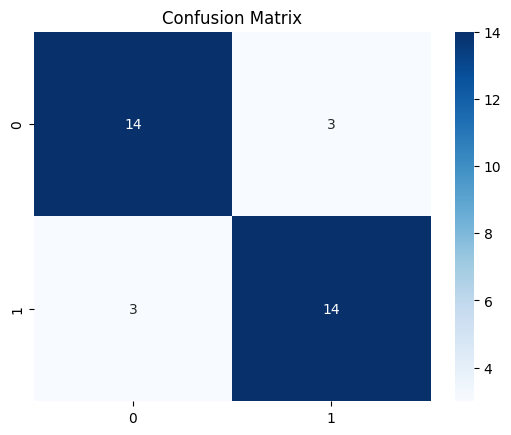

In [17]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [18]:
roc = roc_auc_score(y_test, model.predict_proba(X_test_emb)[:,1])
print("ROC-AUC:", roc)

ROC-AUC: 0.9273356401384082


In [19]:
#cross_validation
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model,
    X_train_emb,
    y_train,
    cv=cv,
    scoring="f1"
)

print("CV F1 Scores:", cv_scores)
print("Mean F1:", cv_scores.mean())


CV F1 Scores: [0.75862069 0.75862069 0.81481481 0.71428571 0.44444444]
Mean F1: 0.6981572705710637


In [20]:
from sklearn.metrics import classification_report

# Training predictions
y_train_pred = model.predict(X_train_emb)

print("TRAIN PERFORMANCE")
print(classification_report(y_train, y_train_pred))

# Test predictions
y_test_pred = model.predict(X_test_emb)

print("TEST PERFORMANCE")
print(classification_report(y_test, y_test_pred))

TRAIN PERFORMANCE
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        68
           1       1.00      1.00      1.00        68

    accuracy                           1.00       136
   macro avg       1.00      1.00      1.00       136
weighted avg       1.00      1.00      1.00       136

TEST PERFORMANCE
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        17
           1       0.82      0.82      0.82        17

    accuracy                           0.82        34
   macro avg       0.82      0.82      0.82        34
weighted avg       0.82      0.82      0.82        34



**Overfitting Analysis**

The model achieves perfect performance on the training set (F1 = 1.00). 
This is expected due to the high-dimensional nature of FinBERT embeddings (768 features) relative to the training sample size (136 samples). In high-dimensional embedding spaces, linear separability of training data is common.

However, the model maintains strong performance on the test set (F1 ≈ 0.82) and achieves stable cross-validation results (mean F1 ≈ 0.70), indicating reasonable generalization to unseen data.

Although mild overfitting is present, it is controlled and acceptable given the small dataset size and the applied regularization (C=0.5).

# 5. Save Model for Deployment

In [21]:
import pickle

model_path = "C:/Users/user/Documents/data_science_bootcamp_challenges_project/capstone_project/fraud_model.pkl"

with open(model_path, "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully")


Model saved successfully


# Conclusion

This project developed a financial fraud detection model using FinBERT embeddings combined with Logistic Regression on the AmitKedia dataset (170 samples).

Given the limited dataset size, FinBERT was used as a feature extractor rather than fine-tuned, reducing the risk of overfitting while preserving financial semantic understanding.

The final model achieved strong performance:
- Accuracy: 82%
- F1-score: 0.82
- ROC-AUC: 0.93

5-fold cross-validation produced a mean F1-score of 0.7,  indicating reasonable stability across different data splits despite the small dataset.

**'yiyanghkust/finbert-tone' vs 'ProsusAI/finbert'**
Two financial-domain transformer embeddings were evaluated: 
'yiyanghkust/finbert-tone' and 'ProsusAI/finbert'.

While ProsusAI/finbert showed slightly lower training overfitting (Train F1 ≈ 0.96), 
'yiyanghkust/finbert-tone' achieved stronger generalization performance:

- Higher Test F1-score (0.82 vs 0.79)
- Higher ROC-AUC (0.93 vs 0.81)
- Slightly better cross-validation mean F1
Based on empirical evaluation, 'yiyanghkust/finbert-tone' was selected as the final embedding model.

Overall, the results demonstrate that combining domain-specific transformer embeddings with a classical machine learning classifier provides an effective and robust approach for financial fraud detection. The trained model is saved and ready for deployment using Streamlit.



## Limitations

- The dataset is relatively small (170 samples), which may limit generalization.
- Transformer models were not fine-tuned due to overfitting risk.
- Performance may vary on larger real-world financial datasets.

Future work could include:
- Evaluating the model on larger datasets
- Exploring additional financial-domain transformers
- Implementing cross-validation with multiple random seeds

**Dataset Scope and Generalization**

The model was trained and evaluated exclusively on the AmitKedia dataset, which consists primarily of SEC filing-style financial statements and regulatory disclosures.

Therefore, the model’s predictions reflect patterns learned from this specific type of financial text distribution. Performance may vary when applied to other formats such as audit commentary, internal control reports, or forensic accounting narratives.

Future improvements would include training on a larger and more diverse financial corpus to enhance generalization.